# MNIST Neural Network Classification

## Project Objective

The goal of this project is to build and compare feedforward neural network models for classifying handwritten digits from the MNIST dataset.

The models are built using Keras and compared using different neural network architectures, numbers of epochs, L2 regularization, and dropout.

For all models:
- ReLU activation is used in the hidden layers.
- Softmax activation is used in the output layer.
- A mini-batch size of 128 is used.
- Model performance is evaluated using training and test error.

In [2]:
import matplotlib.pyplot as plt

print("Matplotlib imported successfully")

Matplotlib imported successfully


In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Import Libraries

The required Python libraries are imported for numerical operations, data visualization, and building neural network models using Keras.

In [7]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

## Load the MNIST Dataset

The MNIST dataset contains grayscale images of handwritten digits from 0 to 9.

The dataset is already divided into:
- a training set used to train the neural network
- a test set used to evaluate how well the trained model performs on unseen images

In [8]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [9]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


### Dataset Information

The MNIST dataset consists of handwritten digit images representing the numbers 0 through 9.

- The training set contains **60,000 images**.
- The test set contains **10,000 images**.
- Each image has a size of **28 × 28 pixels**.
- `X_train` and `X_test` contain the handwritten digit images.
- `y_train` and `y_test` contain the corresponding digit labels.
- Since there are 10 possible digits (0–9), this is a **multiclass classification problem**.

## Explore the MNIST Images

Each observation in the MNIST dataset is a 28 × 28 grayscale image of a handwritten digit. An example image and its corresponding class label are displayed below.

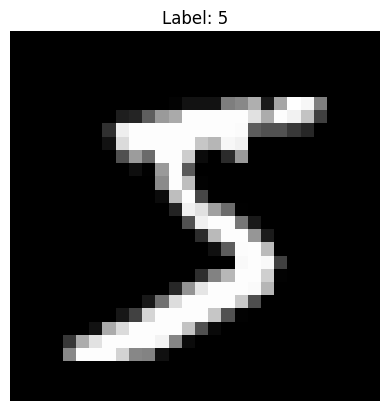

In [14]:
# Display the first training image
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

## Examine Pixel Values

Each MNIST image is represented as a 28 × 28 matrix of pixel intensity values. The pixel values range from 0 to 255, where lower values represent darker pixels and higher values represent brighter pixels.

In [16]:
# Check the range of pixel values
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


## Normalize the Pixel Values

The pixel values are scaled from the original range of 0–255 to a range of 0–1. Normalization helps the neural network train more efficiently and improves numerical stability.

In [17]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Reshape the Input Data

Each MNIST image is originally represented as a 28 × 28 matrix. For the feedforward neural network, each image is flattened into a one-dimensional vector containing 784 pixel values.

In [18]:
# Reshape each 28 x 28 image into 784 input features
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 784)
X_test shape: (10000, 784)


## Prepare the Target Labels

The MNIST target variable contains integer labels from 0 to 9. The labels are converted to one-hot encoded vectors so that they can be used with the 10-unit softmax output layer.

In [19]:
# Convert labels to one-hot encoded vectors
y_train_encoded = keras.utils.to_categorical(y_train, 10)
y_test_encoded = keras.utils.to_categorical(y_test, 10)

print("Original label:", y_train[0])
print("One-hot encoded label:", y_train_encoded[0])

Original label: 5
One-hot encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Model 1: One Hidden Layer with 512 Units

The first feedforward neural network contains one hidden layer with 512 units and ReLU activation. The output layer contains 10 units, corresponding to the 10 digit classes (0–9), with softmax activation for multiclass classification.

In [20]:
# Build Model 1
model_1 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

### Compile Model 1

The model is compiled using the Adam optimizer and categorical cross-entropy loss. Categorical cross-entropy is appropriate because this is a multiclass classification problem with one-hot encoded target labels. Accuracy is used to monitor classification performance.

In [21]:
# Compile Model 1
model_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Train Model 1

Model 1 is trained for 5 epochs using a mini-batch size of 128.

- **Epoch:** One complete pass through all 60,000 training images.
- **Batch size:** The number of training images processed before the model updates its weights.
- With a batch size of 128, each epoch contains approximately:

  **60,000 / 128 ≈ 469 mini-batches**

Therefore, the `469/469` displayed during training means that the model has processed all mini-batches required to complete one epoch.

In [22]:
# Train Model 1
history_1 = model_1.fit(
    X_train,
    y_train_encoded,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8715 - loss: 0.4683
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9658 - loss: 0.1207
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9791 - loss: 0.0708
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9848 - loss: 0.0501
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9909 - loss: 0.0346


In [23]:
# Evaluate Model 1 on training and test data
train_loss_1, train_accuracy_1 = model_1.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_1, test_accuracy_1 = model_1.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_1 = 1 - train_accuracy_1
test_error_1 = 1 - test_accuracy_1

print("Training Error:", train_error_1)
print("Test Error:", test_error_1)

Training Error: 0.006966650485992432
Test Error: 0.019999980926513672


### Model 1 Results

The neural network with one hidden layer of 512 units and 5 epochs achieved a training error of approximately **0.70%** and a test error of approximately **2.00%**. The low test error indicates that the model performs well on unseen MNIST images.

## Model 2: One Hidden Layer with 512 Units and 10 Epochs

This model uses the same architecture as Model 1, but it is trained for 10 epochs instead of 5. This allows us to examine whether additional training improves classification performance.

In [24]:
# Build Model 2
model_2 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile Model 2
model_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 2
history_2 = model_2.fit(
    X_train,
    y_train_encoded,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8775 - loss: 0.4504
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9666 - loss: 0.1144
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9800 - loss: 0.0692
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9872 - loss: 0.0471
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9903 - loss: 0.0360
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9931 - loss: 0.0253
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9957 - loss: 0.0180
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9962 - loss: 0.0143
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9976 - loss: 0.0109
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9984 - loss: 0.0081


In [25]:
# Evaluate Model 2 on training and test data
train_loss_2, train_accuracy_2 = model_2.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_2, test_accuracy_2 = model_2.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_2 = 1 - train_accuracy_2
test_error_2 = 1 - test_accuracy_2

print("Training Error:", train_error_2)
print("Test Error:", test_error_2)

Training Error: 0.0015166401863098145
Test Error: 0.018299996852874756


### Model 2 Results

With 10 epochs, the model achieved a training error of approximately **0.15%** and a test error of approximately **1.83%**. Compared with Model 1, increasing the number of epochs from 5 to 10 reduced both training and test error.

## Model 3: One Hidden Layer with 256 Units and 5 Epochs

This model uses one hidden layer with 256 units and ReLU activation. Compared with Model 1, the hidden layer is smaller, allowing us to examine whether fewer hidden units affect classification performance.

In [26]:
# Build Model 3
model_3 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile Model 3
model_3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 3
history_3 = model_3.fit(
    X_train,
    y_train_encoded,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8468 - loss: 0.5433
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9596 - loss: 0.1422
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9732 - loss: 0.0936
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9819 - loss: 0.0661
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9856 - loss: 0.0519


In [27]:
# Evaluate Model 3 on training and test data
train_loss_3, train_accuracy_3 = model_3.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_3, test_accuracy_3 = model_3.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_3 = 1 - train_accuracy_3
test_error_3 = 1 - test_accuracy_3

print("Training Error:", train_error_3)
print("Test Error:", test_error_3)

Training Error: 0.012566685676574707
Test Error: 0.02319997549057007


### Model 3 Results

The model with 256 hidden units and 5 epochs achieved a training error of approximately **1.26%** and a test error of approximately **2.32%**. Compared with Model 1, which used 512 hidden units for the same number of epochs, Model 3 produced slightly higher training and test errors. In this case, the larger hidden layer provided better classification performance.

## Model 4: One Hidden Layer with 256 Units and 10 Epochs

This model uses one hidden layer with 256 units and ReLU activation and is trained for 10 epochs. Comparing this model with Model 3 shows whether additional training improves performance for the smaller hidden-layer architecture.

In [28]:
# Build Model 4
model_4 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile Model 4
model_4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 4
history_4 = model_4.fit(
    X_train,
    y_train_encoded,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8559 - loss: 0.5278
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9588 - loss: 0.1400
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9729 - loss: 0.0938
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9805 - loss: 0.0695
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9854 - loss: 0.0516
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9884 - loss: 0.0415
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9909 - loss: 0.0324
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9937 - loss: 0.0244
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9954 - loss: 0.0196
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9964 - loss: 0.0158


In [29]:
# Evaluate Model 4 on training and test data
train_loss_4, train_accuracy_4 = model_4.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_4, test_accuracy_4 = model_4.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_4 = 1 - train_accuracy_4
test_error_4 = 1 - test_accuracy_4

print("Training Error:", train_error_4)
print("Test Error:", test_error_4)

Training Error: 0.001483321189880371
Test Error: 0.019900023937225342


### Model 4 Results

The model with 256 hidden units and 10 epochs achieved a training error of approximately **0.15%** and a test error of approximately **1.99%**. Compared with Model 3, increasing the number of epochs from 5 to 10 reduced both training and test error, indicating improved classification performance.

## Model 5: Two Hidden Layers with 512 Units Each and 5 Epochs

This model uses two hidden layers, with 512 units in each layer and ReLU activation. Compared with the previous models, this network is deeper and can learn more complex patterns from the MNIST images.

In [30]:
# Build Model 5
model_5 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile Model 5
model_5.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 5
history_5 = model_5.fit(
    X_train,
    y_train_encoded,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8846 - loss: 0.3974
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9756 - loss: 0.0797
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9849 - loss: 0.0489
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9892 - loss: 0.0336
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9916 - loss: 0.0263


In [31]:
# Evaluate Model 5 on training and test data
train_loss_5, train_accuracy_5 = model_5.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_5, test_accuracy_5 = model_5.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_5 = 1 - train_accuracy_5
test_error_5 = 1 - test_accuracy_5

print("Training Error:", train_error_5)
print("Test Error:", test_error_5)

Training Error: 0.009400010108947754
Test Error: 0.023899972438812256


### Model 5 Results

The model with two hidden layers of 512 units each and 5 epochs achieved a training error of approximately **0.94%** and a test error of approximately **2.39%**. In this run, adding a second hidden layer did not improve performance compared with Model 1.

## Model 6: Two Hidden Layers with 512 Units Each and 10 Epochs

This model uses two hidden layers with 512 units in each layer and ReLU activation. It is trained for 10 epochs to examine whether additional training improves the performance of the deeper network.

In [32]:
# Build Model 6
model_6 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile Model 6
model_6.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 6
history_6 = model_6.fit(
    X_train,
    y_train_encoded,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8860 - loss: 0.3980
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9749 - loss: 0.0813
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9851 - loss: 0.0453
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9882 - loss: 0.0367
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9912 - loss: 0.0269
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9942 - loss: 0.0181
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9932 - loss: 0.0188
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9944 - loss: 0.0157
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9954 - loss: 0.0141
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9967 - loss: 0.0111


In [33]:
# Evaluate Model 6 on training and test data
train_loss_6, train_accuracy_6 = model_6.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_6, test_accuracy_6 = model_6.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_6 = 1 - train_accuracy_6
test_error_6 = 1 - test_accuracy_6

print("Training Error:", train_error_6)
print("Test Error:", test_error_6)

Training Error: 0.0013833045959472656
Test Error: 0.017099976539611816


### Model 6 Results

The model with two hidden layers of 512 units each and 10 epochs achieved a training error of approximately **0.14%** and a test error of approximately **1.71%**. Compared with Model 5, increasing the number of epochs from 5 to 10 reduced both training and test error.

Among the models evaluated so far, Model 6 has the lowest test error.

## Model 7: Two Hidden Layers with 256 Units Each and 5 Epochs

This model uses two hidden layers with 256 units in each layer and ReLU activation. It is trained for 5 epochs to compare a smaller deep network with the larger two-layer models.

In [34]:
# Build Model 7
model_7 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile Model 7
model_7.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 7
history_7 = model_7.fit(
    X_train,
    y_train_encoded,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8606 - loss: 0.4848
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9686 - loss: 0.1049
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9799 - loss: 0.0663
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9864 - loss: 0.0432
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9908 - loss: 0.0307


In [35]:
# Evaluate Model 7 on training and test data
train_loss_7, train_accuracy_7 = model_7.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_7, test_accuracy_7 = model_7.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_7 = 1 - train_accuracy_7
test_error_7 = 1 - test_accuracy_7

print("Training Error:", train_error_7)
print("Test Error:", test_error_7)

Training Error: 0.010333359241485596
Test Error: 0.024200022220611572


### Model 7 Results

The model with two hidden layers of 256 units each and 5 epochs achieved a training error of approximately **1.03%** and a test error of approximately **2.42%**. The test error is slightly higher than the training error, indicating that the model performs somewhat better on the training data than on unseen test data.

## Model 8: Two Hidden Layers with 256 Units Each and 10 Epochs

This model uses two hidden layers with 256 units in each layer and ReLU activation. It is trained for 10 epochs to determine whether additional training improves the performance of this smaller deep network.

In [36]:
# Build Model 8
model_8 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile Model 8
model_8.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 8
history_8 = model_8.fit(
    X_train,
    y_train_encoded,
    epochs=10,
    batch_size=128
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8643 - loss: 0.4815
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9686 - loss: 0.1035
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9810 - loss: 0.0631
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9873 - loss: 0.0433
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9911 - loss: 0.0306
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9923 - loss: 0.0240
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9945 - loss: 0.0178
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9962 - loss: 0.0126
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9950 - loss: 0.0147
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9954 - loss: 0.0134


In [37]:
# Evaluate Model 8 on training and test data
train_loss_8, train_accuracy_8 = model_8.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_8, test_accuracy_8 = model_8.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_8 = 1 - train_accuracy_8
test_error_8 = 1 - test_accuracy_8

print("Training Error:", train_error_8)
print("Test Error:", test_error_8)

Training Error: 0.005349993705749512
Test Error: 0.021799981594085693


### Model 8 Results

The model with two hidden layers of 256 units each and 10 epochs achieved a training error of approximately **0.53%** and a test error of approximately **2.18%**. Compared with Model 7, increasing the number of epochs from 5 to 10 reduced both training and test error.

## Model 9: L2 Regularization

This model uses the same architecture as Model 1, with one hidden layer of 512 units and 5 epochs, but adds L2 weight regularization with λ = 0.001.

L2 regularization adds a penalty for very large weights, which can help reduce overfitting and improve generalization to unseen data.

In [38]:
# Build Model 9 with L2 regularization
model_9 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(
        512,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dense(10, activation="softmax")
])

# Compile Model 9
model_9.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 9
history_9 = model_9.fit(
    X_train,
    y_train_encoded,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8640 - loss: 0.7945
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9574 - loss: 0.2600
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9658 - loss: 0.2068
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9696 - loss: 0.1829
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9743 - loss: 0.1708


In [39]:
# Evaluate Model 9 on training and test data
train_loss_9, train_accuracy_9 = model_9.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_9, test_accuracy_9 = model_9.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_9 = 1 - train_accuracy_9
test_error_9 = 1 - test_accuracy_9

print("Training Error:", train_error_9)
print("Test Error:", test_error_9)

Training Error: 0.020983338356018066
Test Error: 0.026099979877471924


### Model 9 Results

The L2-regularized model achieved a training error of approximately **2.10%** and a test error of approximately **2.61%**. Compared with Model 1, adding L2 regularization with λ = 0.001 increased both training and test error. Therefore, L2 regularization did not improve classification performance for this model and setting.

## Model 10: Dropout Regularization

This model uses the same architecture as Model 1, but adds a 50% dropout layer after the hidden layer.

During training, dropout randomly turns off 50% of the hidden units for each mini-batch. This reduces the model's dependence on specific neurons and can help reduce overfitting.

In [40]:
# Build Model 10 with 50% dropout
model_10 = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile Model 10
model_10.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model 10
history_10 = model_10.fit(
    X_train,
    y_train_encoded,
    epochs=5,
    batch_size=128
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8369 - loss: 0.5501
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9504 - loss: 0.1680
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9653 - loss: 0.1197
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9715 - loss: 0.0958
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9746 - loss: 0.0844


In [41]:
# Evaluate Model 10 on training and test data
train_loss_10, train_accuracy_10 = model_10.evaluate(
    X_train, y_train_encoded, verbose=0
)

test_loss_10, test_accuracy_10 = model_10.evaluate(
    X_test, y_test_encoded, verbose=0
)

train_error_10 = 1 - train_accuracy_10
test_error_10 = 1 - test_accuracy_10

print("Training Error:", train_error_10)
print("Test Error:", test_error_10)

Training Error: 0.012783348560333252
Test Error: 0.023599982261657715


### Model 10 Results

The model with 50% dropout achieved a training error of approximately **1.28%** and a test error of approximately **2.36%**. Compared with Model 1, dropout increased both training and test error. Therefore, 50% dropout did not improve classification performance for this model and setting.

## Model Performance Comparison

The table below summarizes the training and test errors for all neural network architectures. The models differ in the number of hidden layers, hidden units, training epochs, and regularization methods.

In [42]:
# Create a comparison table for all models
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Model 1", "Model 2", "Model 3", "Model 4", "Model 5",
        "Model 6", "Model 7", "Model 8", "Model 9", "Model 10"
    ],
    "Hidden Layers": [1, 1, 1, 1, 2, 2, 2, 2, 1, 1],
    "Units": [
        "512", "512", "256", "256",
        "512-512", "512-512", "256-256", "256-256",
        "512", "512"
    ],
    "Epochs": [5, 10, 5, 10, 5, 10, 5, 10, 5, 5],
    "Regularization": [
        "None", "None", "None", "None",
        "None", "None", "None", "None",
        "L2 (0.001)", "Dropout (50%)"
    ],
    "Training Error (%)": [
        train_error_1 * 100,
        train_error_2 * 100,
        train_error_3 * 100,
        train_error_4 * 100,
        train_error_5 * 100,
        train_error_6 * 100,
        train_error_7 * 100,
        train_error_8 * 100,
        train_error_9 * 100,
        train_error_10 * 100
    ],
    "Test Error (%)": [
        test_error_1 * 100,
        test_error_2 * 100,
        test_error_3 * 100,
        test_error_4 * 100,
        test_error_5 * 100,
        test_error_6 * 100,
        test_error_7 * 100,
        test_error_8 * 100,
        test_error_9 * 100,
        test_error_10 * 100
    ]
})

results.round(2)

,Model,Hidden Layers,Units,Epochs,Regularization,Training Error (%),Test Error (%)
0,Model 1,1,512,5,None,0.70,2.00
1,Model 2,1,512,10,None,0.15,1.83
2,Model 3,1,256,5,None,1.26,2.32
3,Model 4,1,256,10,None,0.15,1.99
4,Model 5,2,512-512,5,None,0.94,2.39
5,Model 6,2,512-512,10,None,0.14,1.71
6,Model 7,2,256-256,5,None,1.03,2.42
7,Model 8,2,256-256,10,None,0.53,2.18
8,Model 9,1,512,5,L2 (0.001),2.10,2.61
9,Model 10,1,512,5,Dropout (50%),1.28,2.36


### Comparison of Model Performance

The neural network models showed differences in performance depending on the number of hidden layers, hidden units, epochs, and regularization method.

Overall, increasing the number of training epochs from 5 to 10 generally reduced the test error. The best-performing model was **Model 6**, which used two hidden layers with 512 units each and was trained for 10 epochs. It achieved the lowest test error of approximately **1.71%**, corresponding to a test accuracy of approximately **98.29%**.

Models trained for only 5 epochs generally had higher test errors. The L2-regularized model and the dropout model did not improve test performance under the settings used in this analysis.

Therefore, **Model 6 (512-512 hidden units, 10 epochs)** is recommended based on its lowest test error.

## Visualization of Model Performance

The training and test errors of all neural network models are compared below. This visualization helps identify differences in generalization performance across the architectures and regularization methods.

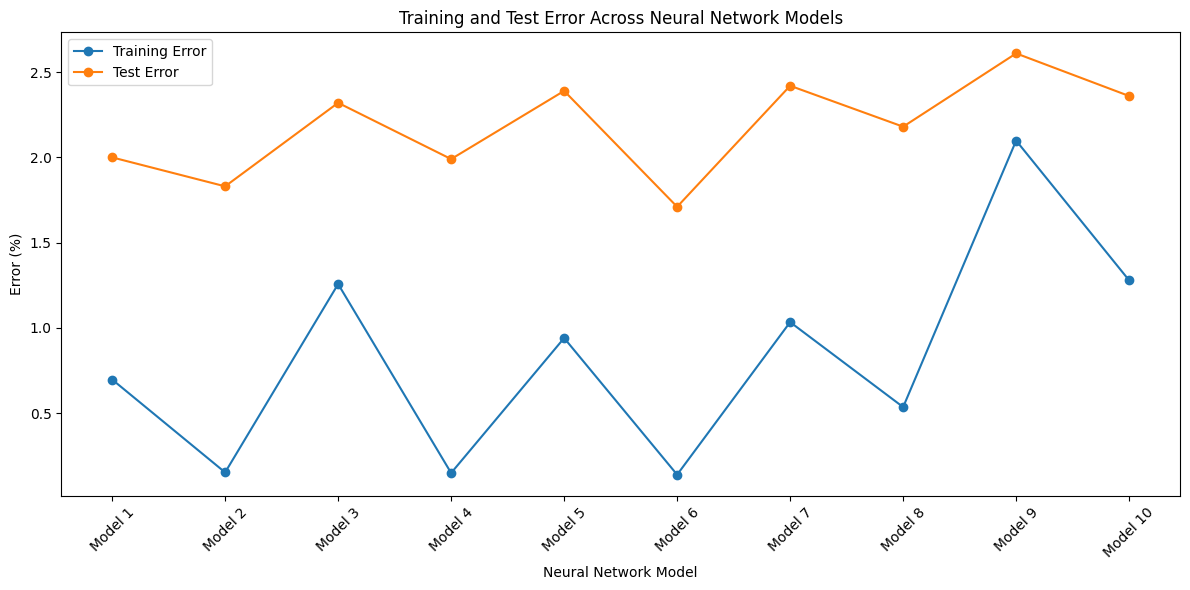

In [43]:
# Plot training and test error for all models
x = np.arange(len(results))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    results["Training Error (%)"],
    marker="o",
    label="Training Error"
)

plt.plot(
    x,
    results["Test Error (%)"],
    marker="o",
    label="Test Error"
)

plt.xticks(x, results["Model"], rotation=45)
plt.xlabel("Neural Network Model")
plt.ylabel("Error (%)")
plt.title("Training and Test Error Across Neural Network Models")
plt.legend()
plt.tight_layout()

# Save figure for GitHub
plt.savefig("Figures/model_error_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The comparison plot shows that training error is generally lower than test error across the models. Models trained for 10 epochs generally achieved lower test errors than their corresponding 5-epoch models.

Model 6, with two hidden layers of 512 units each and 10 epochs, achieved the lowest test error of approximately **1.71%** and provided the best overall classification performance. L2 regularization and 50% dropout did not improve test performance under the settings evaluated.

## Predicted Digits from the Best Model

The best-performing model is used to predict several images from the MNIST test set. The predicted labels are compared with the true labels to provide a visual interpretation of model performance.

In [44]:
# Predict classes for the test set using Model 6
predictions = model_6.predict(X_test, verbose=0)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

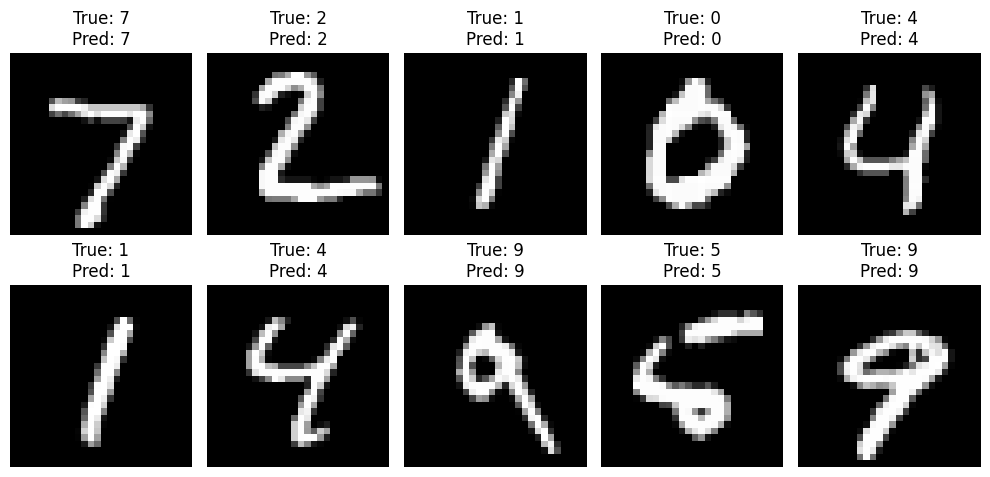

In [45]:
# Display test images with true and predicted labels
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Reshape the 784 pixels back to a 28 x 28 image
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    
    plt.title(
        f"True: {y_test[i]}\nPred: {predicted_labels[i]}"
    )
    
    plt.axis("off")

plt.tight_layout()

# Save figure for GitHub
plt.savefig(
    "Figures/model6_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Prediction Interpretation

Model 6 correctly classified all 10 test images displayed above. The predicted digit labels match the true labels for each example, providing a visual demonstration of the model's ability to recognize unseen handwritten digits.

Although these examples illustrate successful predictions, the overall test error of **1.71%** provides a more reliable measure of model performance across the complete test set of 10,000 images.

## Conclusion

In this project, multiple feedforward neural network architectures were developed and compared for MNIST handwritten digit classification using Keras. The models were evaluated by varying the number of hidden layers, hidden units, training epochs, and regularization methods.

Overall, models trained for 10 epochs generally achieved lower test errors than their corresponding 5-epoch models. Increasing the number of hidden units and network depth also improved performance for some architectures.

Among all models evaluated, **Model 6**, with two hidden layers of 512 units each and 10 epochs, achieved the best performance with a training error of approximately **0.14%** and a test error of approximately **1.71%**, corresponding to a test accuracy of approximately **98.29%**.

L2 regularization with λ = 0.001 and 50% dropout did not improve test performance under the settings evaluated in this analysis.

Based on the lowest test error, **Model 6 is recommended as the best-performing neural network architecture for this analysis**.